# Analysis of K3 Tensor Slopes vs Width (M)

We analyze how the slopes of K3 tensor norms scale with respect to network width (M).


N = 8:
Infinity Norm Slope Fit:
R^2: 0.548
p-value: 3.807e-03
Max Eigenvalue Slope Fit:
R^2: 0.675
p-value: 5.722e-04

N = 16:
Infinity Norm Slope Fit:
R^2: 0.073
p-value: 5.566e-01
Max Eigenvalue Slope Fit:
R^2: 0.078
p-value: 5.441e-01


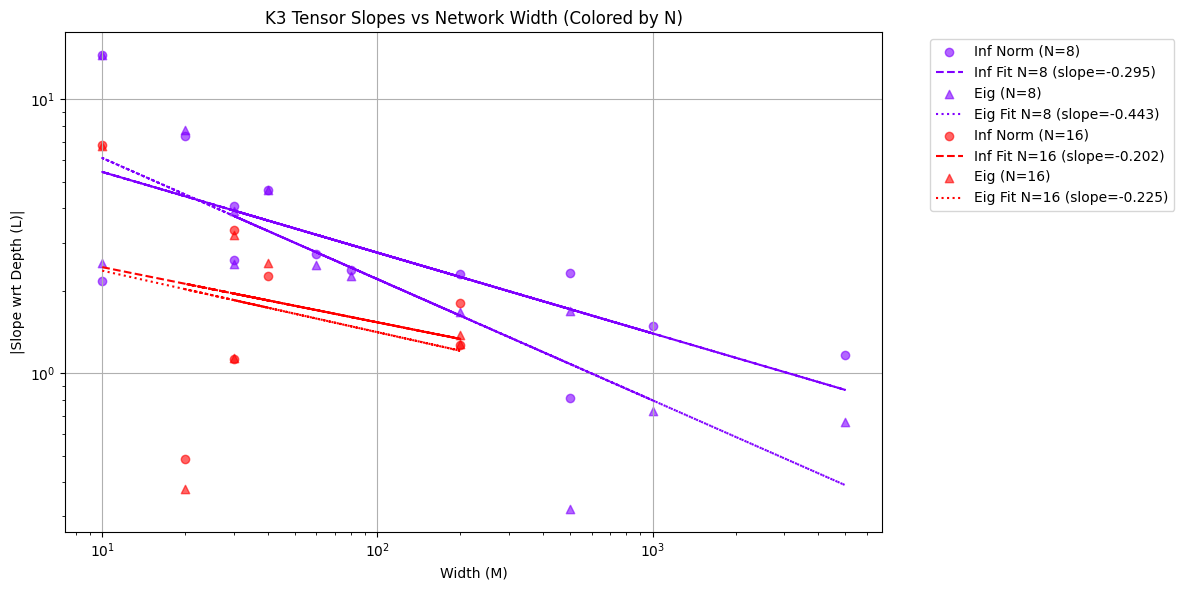

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# i read the slopes data from the file
with open('kernel3_slopes_L.txt', 'r') as f:
    lines = f.readlines()[3:]  # i skip header lines

# i parse the data
data = []
for line in lines:
    if '|' not in line:
        continue
    parts = line.strip().split('|')
    config = parts[0].strip()
    slope_inf = -float(parts[1].strip())  # i take negative of slope
    slope_eig = -float(parts[2].strip())  # i take negative of slope
    r2 = float(parts[3].strip())
    points = int(parts[4].strip())
    
    # i extract M and N values from config
    M = int(config.split('M=')[1].split()[0])
    N = int(config.split('N=')[1].split(',')[0])
    data.append((M, N, slope_inf, slope_eig, r2, points))

# i get unique N values
unique_N = sorted(list(set(d[1] for d in data)))
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_N)))

plt.figure(figsize=(12, 6))

# i plot separately for each N value
for N, color in zip(unique_N, colors):
    N_data = [d for d in data if d[1] == N]
    if len(N_data) < 2:  # i skip if not enough points
        continue
        
    M_values = np.array([d[0] for d in N_data])
    slope_inf_values = np.array([d[2] for d in N_data])
    slope_eig_values = np.array([d[3] for d in N_data])
    
    # i plot infinity norm slopes
    slope_inf_fit = linregress(np.log10(M_values), np.log10(np.abs(slope_inf_values)))
    plt.scatter(M_values, np.abs(slope_inf_values), color=color, marker='o', 
                label=f'Inf Norm (N={N})', alpha=0.6)
    plt.plot(M_values, 10**(slope_inf_fit.slope * np.log10(M_values) + slope_inf_fit.intercept),
             '--', color=color, label=f'Inf Fit N={N} (slope={slope_inf_fit.slope:.3f})')
    
    # i plot eigenvalue slopes
    slope_eig_fit = linregress(np.log10(M_values), np.log10(np.abs(slope_eig_values)))
    plt.scatter(M_values, np.abs(slope_eig_values), color=color, marker='^',
                label=f'Eig (N={N})', alpha=0.6)
    plt.plot(M_values, 10**(slope_eig_fit.slope * np.log10(M_values) + slope_eig_fit.intercept),
             ':', color=color, label=f'Eig Fit N={N} (slope={slope_eig_fit.slope:.3f})')
    
    # i print fit statistics for each N
    print(f"\nN = {N}:")
    print(f"Infinity Norm Slope Fit:")
    print(f"R^2: {slope_inf_fit.rvalue**2:.3f}")
    print(f"p-value: {slope_inf_fit.pvalue:.3e}")
    print("Max Eigenvalue Slope Fit:")
    print(f"R^2: {slope_eig_fit.rvalue**2:.3f}")
    print(f"p-value: {slope_eig_fit.pvalue:.3e}")

plt.xscale('log')
plt.yscale('log')  # i add log scale for y axis
plt.xlabel('Width (M)')
plt.ylabel('|Slope wrt Depth (L)|')  # i update y label to reflect absolute value
plt.title('K3 Tensor Slopes vs Network Width (Colored by N)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()